# Poker Dataset Exploration
Absolute Poker NLH 2009 â€” population study

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from parser import load_file, load_directory
from hand_utils import hand_summary, assign_positions, final_pot, count_preflop_raises

## Load hands

In [3]:
DATA_FILE = '../abs NLH handhq_1-OBFUSCATED.phhs'

hands = load_file(DATA_FILE)
print(f'Loaded {len(hands):,} hands')

Loaded 1,000 hands


## Build summary DataFrame

In [4]:
rows = [hand_summary(h) for h in hands]
df = pd.DataFrame(rows)
df.head()

,hand_id,file,date,table,n_players,pot_final,n_preflop_raises,went_to_showdown,is_multiway,n_actions,has_winnings
0,3017235114,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,DEFIANCE ST,5,1.50,0,False,False,9,True
1,3017237934,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,1.50,0,False,False,3,True
2,3017234966,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,MORGAN CT,6,3.25,1,False,False,12,True
3,3017238288,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,1.75,0,False,False,6,True
4,3017238782,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,2.50,1,False,False,4,True


In [5]:
df.describe()

,hand_id,n_players,pot_final,n_preflop_raises,n_actions
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.017338e+09,5.610000,11.708930,0.614000,18.157000
std,5.335087e+04,2.141141,18.094909,0.653782,7.998896
min,3.017235e+09,2.000000,1.000000,0.000000,3.000000
25%,3.017293e+09,5.000000,2.750000,0.000000,12.000000
50%,3.017341e+09,6.000000,4.750000,1.000000,18.000000
75%,3.017384e+09,7.000000,11.250000,1.000000,24.000000
max,3.017436e+09,9.000000,188.510000,5.000000,44.000000


## Player count distribution

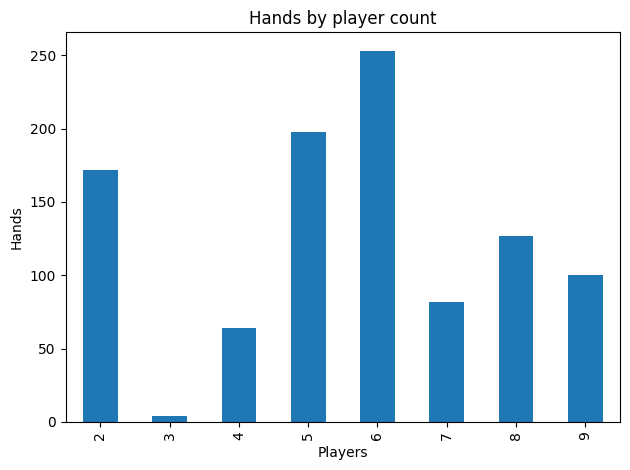

In [6]:
df['n_players'].value_counts().sort_index().plot(kind='bar', title='Hands by player count')
plt.xlabel('Players')
plt.ylabel('Hands')
plt.tight_layout()
plt.show()

## Pot size distribution

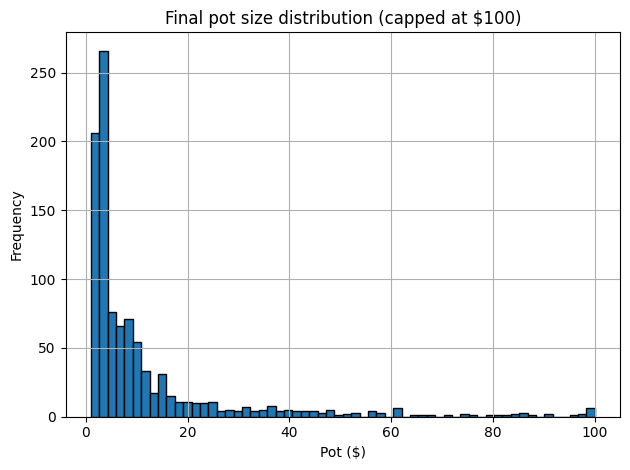

In [7]:
df['pot_final'].clip(upper=100).hist(bins=60, edgecolor='black')

plt.title('Final pot size distribution (capped at $100)')
plt.xlabel('Pot ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 
Preflop aggression

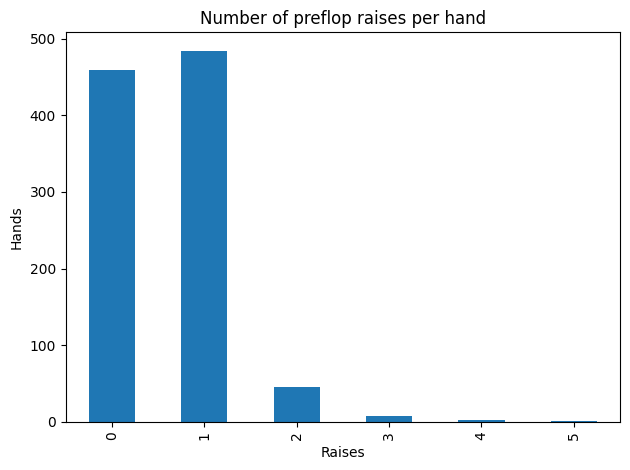

3bet+ rate: 5.7%
4bet+ rate: 1.1%


In [8]:

df['n_preflop_raises'].value_counts().sort_index().plot(
    kind='bar', title='Number of preflop raises per hand')
plt.xlabel('Raises')
plt.ylabel('Hands')
plt.tight_layout()
plt.show()

print('3bet+ rate: {:.1%}'.format((df['n_preflop_raises'] >= 2).mean()))
print('4bet+ rate: {:.1%}'.format((df['n_preflop_raises'] >= 3).mean()))

## Showdown rate

In [9]:
sd_rate = df['went_to_showdown'].mean()
print(f'Showdown rate: {sd_rate:.1%}')

Showdown rate: 29.2%


## Tables

In [10]:
df['table'].value_counts().head(20)

table
CAMERON ST     149
DEFIANCE ST    104
DOHENY AVE      97
ENGLAND AVE     92
JARVIS AVE      72
DAISY DR        70
MARINER DR      68
ALATNA AVE      64
CHAPEL HILL     63
BAGPIPE AVE     61
BRADFORD DR     54
MORGAN CT       42
CANADA HWY      41
GERMANY HWY     23
Name: count, dtype: int64

## Sample hand inspection

In [11]:
h = hands[20]   # change index to explore different hands
print(f'Hand {h.hand_id}  table={h.table}  date={h.date_str}')
print(f'Players ({h.n_players}): {h.players}')
print(f'Stacks: {h.starting_stacks}')
print(f'Blinds: {h.blinds_or_straddles}')
print(f'Winnings: {h.winnings}')
print()
print('Actions:')
for i, a in enumerate(h.actions):
    print(f'  [{i:2d}] {a}')

Hand 3017240534  table=DEFIANCE ST  date=2009-07-01
Players (5): ['C71mm6MhFIxjPW1vaAXL1g', '7cQYg8zQz/9uOLzp1GN8wQ', 'Qt5Yyd/Y121jtIk37c7TSg', 'l1bCLGuFqeFRwUfPsiDu/g', '13/ez0NPA4uRcBJ1Rafl6A']
Stacks: [54.8, 23.2, 12.07, 144.94, 17.15]
Blinds: [0.25, 0.5, 0.0, 0.0, 0.0]
Winnings: None

Actions:
  [ 0] d dh p1 ????
  [ 1] d dh p2 ????
  [ 2] d dh p3 ????
  [ 3] d dh p4 ????
  [ 4] d dh p5 ????
  [ 5] p3 f
  [ 6] p4 f
  [ 7] p5 cc
  [ 8] p1 cc
  [ 9] p2 cc
  [10] d db 7cAh7d
  [11] p1 cc
  [12] p2 cc
  [13] p5 cc
  [14] d db 4d
  [15] p1 cc
  [16] p2 cc
  [17] p5 cc
  [18] d db 4c
  [19] p1 cc
  [20] p2 cc
  [21] p5 cc
  [22] p1 sm 8c9s
  [23] p2 sm 8d5d
  [24] p5 sm Kd9h


## Run auto-labeller and check results

In [12]:
from labeller import label_hand, get_connection, insert_labels

conn = get_connection()
total_inserted = 0
for h in hands:
    rows_lbl = label_hand(h)
    total_inserted += insert_labels(rows_lbl, conn)
conn.close()
print(f'Inserted {total_inserted:,} label rows')

Inserted 4,202 label rows


In [13]:
from analyser import Analyser

an = Analyser()
print(an.summary())
print()

counts_df = an.label_counts_df()
counts_df

{'total_labelled_hands': 910, 'total_label_rows': 6409, 'unique_labels': 174}



,label,count
0,rfi,484
1,single_raised_pot,484
2,heads_up_flop,437
3,flop_two_tone,396
4,limp_pot,369
...,...,...
169,hand_Q6s,1
170,hand_Q8s,1
171,hand_T3o,1
172,hand_T7o,1


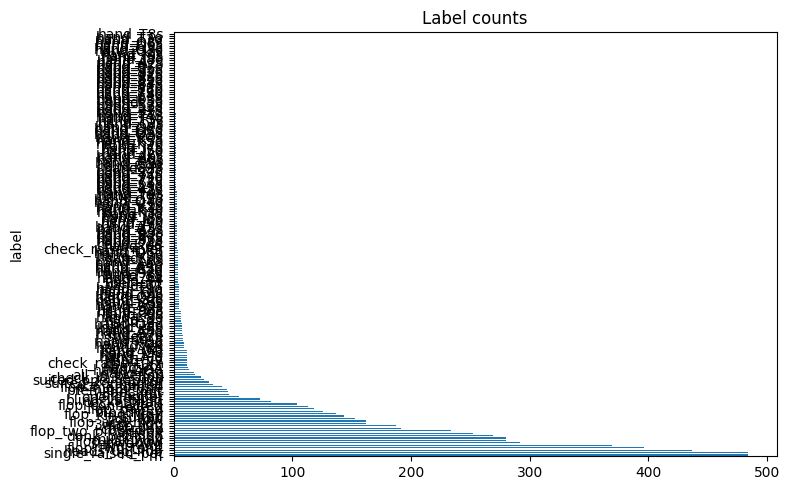

In [14]:
counts_df.set_index('label')['count'].plot(
    kind='barh', title='Label counts', figsize=(8, 5))
plt.tight_layout()
plt.show()

---
## Player earnings & filtering (`db/poker.db`)

Queries against the `player_hands` table populated by `src/ingest.py`.

In [15]:
import sqlite3

con = sqlite3.connect('../db/poker.db')
n_rows = con.execute('SELECT COUNT(*) FROM player_hands').fetchone()[0]
n_hands = con.execute('SELECT COUNT(DISTINCT hand_id) FROM player_hands').fetchone()[0]
print(f'{n_rows:,} player-hand rows across {n_hands:,} hands')

62,419,323 player-hand rows across 10,935,505 hands


### Earnings leaderboard

In [ ]:
earnings = pd.read_sql("""
    SELECT player_id,
           COUNT(*)                        hands,
           ROUND(SUM(net_won), 2)          net_won,
           ROUND(AVG(net_won), 4)          avg_per_hand
    FROM player_hands
    WHERE net_won IS NOT NULL
    GROUP BY player_id
    HAVING hands >= 5
    ORDER BY net_won DESC
""", con)

print(f'Players with 5+ hands (net P&L): {len(earnings)}')
display(earnings.head(15))
print()
print('Top 10 losers:')
display(earnings.tail(10).iloc[::-1].reset_index(drop=True))

In [ ]:
top20 = earnings.head(20).copy()
top20['label'] = top20['player_id'].str[:8]
top20.set_index('label')['net_won'].plot(
    kind='bar', figsize=(12, 4), color='steelblue',
    title='Top 20 players by net P&L (truncated player ID)')
plt.ylabel('Net P&L ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Rake analysis

Rake = `sum(invested) - sum(winnings)` per hand (only computable for hands where all winnings are known).
Each player's share is proportional to their investment in that hand.

In [ ]:
# Per-hand rake (hands where every player's winnings are known)
rake_summary = pd.read_sql("""
    WITH hand_rake AS (
        SELECT hand_id,
               SUM(invested)              total_invested,
               SUM(winnings)              total_winnings,
               SUM(invested) - SUM(winnings) rake
        FROM player_hands
        GROUP BY hand_id
        HAVING SUM(CASE WHEN winnings IS NULL THEN 1 ELSE 0 END) = 0
    )
    SELECT COUNT(*)                         raked_hands,
           ROUND(SUM(rake), 2)              total_rake,
           ROUND(AVG(rake), 4)              avg_rake_per_hand,
           ROUND(AVG(100.0 * rake / total_invested), 2) avg_rake_pct
    FROM hand_rake
    WHERE rake >= 0
""", con).iloc[0]
print(f"Hands with known rake:  {int(rake_summary['raked_hands'])}")
print(f"Total rake collected:   ${rake_summary['total_rake']:.2f}")
print(f"Avg rake per hand:      ${rake_summary['avg_rake_per_hand']:.4f}")
print(f"Avg rake as % of pot:   {rake_summary['avg_rake_pct']:.2f}%")

# Per-player rake leaderboard
rake_df = pd.read_sql("""
    WITH hand_rake AS (
        SELECT hand_id,
               SUM(invested)                 total_invested,
               SUM(invested) - SUM(winnings) rake
        FROM player_hands
        GROUP BY hand_id
        HAVING SUM(CASE WHEN winnings IS NULL THEN 1 ELSE 0 END) = 0
          AND SUM(invested) - SUM(winnings) >= 0
    )
    SELECT ph.player_id,
           COUNT(*)                                                         hands,
           ROUND(SUM(ph.invested), 2)                                       total_invested,
           ROUND(SUM(hr.rake * ph.invested / hr.total_invested), 2)         rake_paid,
           ROUND(SUM(ph.net_won), 2)                                        net_won,
           ROUND(SUM(ph.net_won)
               + SUM(hr.rake * ph.invested / hr.total_invested), 2)         net_won_pre_rake
    FROM player_hands ph
    JOIN hand_rake hr ON ph.hand_id = hr.hand_id
    WHERE ph.net_won IS NOT NULL
    GROUP BY ph.player_id
    HAVING hands >= 5
    ORDER BY net_won_pre_rake DESC
""", con)

print(f'\nPlayers with 5+ hands (pre-rake leaderboard): {len(rake_df)}')
display(rake_df.head(15))
print()
print('Top 10 losers (pre-rake):')
display(rake_df.tail(10).iloc[::-1].reset_index(drop=True))

### Positional profitability

In [ ]:
pos_stats = pd.read_sql("""
    SELECT position,
           n_players,
           COUNT(*)                                              hands,
           ROUND(SUM(net_won), 2)                               net_won,
           ROUND(AVG(net_won), 4)                               avg_per_hand,
           ROUND(100.0 * SUM(saw_flop)   / COUNT(*), 1)        flop_seen_pct,
           ROUND(100.0 * SUM(went_to_sd) / COUNT(*), 1)        showdown_pct
    FROM player_hands
    GROUP BY position, n_players ORDER BY n_players, net_won DESC
""", con)
pos_stats

In [ ]:
# Chart uses 6-max hands only (n_players == 6) so positions are comparable
pos_order = ['BTN', 'CO', 'HJ', 'UTG', 'SB', 'BB']
ps6 = (pos_stats[pos_stats['n_players'] == 6]
       .set_index('position')
       .reindex(pos_order))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ps6['net_won'].plot(kind='bar', ax=axes[0], color='steelblue',
                    title='Net P&L by position (6-max)')
axes[0].set_ylabel('Net P&L ($)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=0)

ps6['flop_seen_pct'].plot(kind='bar', ax=axes[1], color='darkorange',
                           title='Flop seen % by position (6-max)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Earnings by pot type

Join `player_hands` with `labels` to slice stats by preflop situation.

In [ ]:
pot_types = ['limp_pot', 'single_raised_pot', '3bet_pot', '4bet_pot', 'squeeze']
rows = []
for label in pot_types:
    r = pd.read_sql("""
        SELECT COUNT(DISTINCT ph.hand_id)              unique_hands,
               ROUND(SUM(ph.net_won), 2)               net_won,
               ROUND(100.0 * SUM(ph.went_to_sd)
                     / COUNT(*), 1)                    sd_pct,
               ROUND(100.0 * SUM(ph.saw_flop)
                     / COUNT(*), 1)                    flop_seen_pct
        FROM player_hands ph
        JOIN labels l ON ph.hand_id = l.hand_id
        WHERE l.label = ? AND ph.net_won IS NOT NULL
    """, con, params=[label]).iloc[0].to_dict()
    r['pot_type'] = label
    rows.append(r)

pd.DataFrame(rows).set_index('pot_type')

### Player deep-dive

Break down the top earner's results by position and situation type.

---
## 888poker Hands Analysis — ScottyWotty

Own hand histories from 888poker Snap (fast-fold) cash games. Unlike the Absolute Poker population study, the hero's hole cards are known for every hand, enabling hand-strength analysis. Dollar amounts are real money.

In [ ]:
import sys
sys.path.insert(0, '../src')

import sqlite3
import re as _re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

from pathlib import Path
from parser_888 import load_file_888

con = sqlite3.connect('../db/poker.db')

_888_dir = Path('../data/888poker')
hands_888 = []
for _f in sorted(_888_dir.glob('*.txt')):
    if 'Summary' not in _f.name:
        hands_888.extend(load_file_888(_f))
print(f'Loaded {len(hands_888):,} 888poker hands')

sw = pd.read_sql("""
    SELECT hand_id, file, position, stack, invested, winnings, net_won,
           saw_flop, went_to_sd, vpip, pfr
    FROM player_hands
    WHERE player_id = 'ScottyWotty' AND venue = '888poker'
""", con)
print(f'ScottyWotty: {len(sw):,} hands in db')
print(f'Net P&L: ${sw["net_won"].sum():.2f}')

### Stake P&L with rake

In [ ]:

# --- Stake P&L with rake breakdown ---
import re as _re
_stake_pat = _re.compile(r'\$([0-9.]+)-\$([0-9.]+)')

def _bb(fname):
    m = _stake_pat.search(fname)
    return float(m.group(2)) if m else None

sw_stake = sw.copy()
sw_stake['bb']    = sw_stake['file'].map(_bb)
sw_stake['stake'] = sw_stake['bb'].map(lambda b: f'NL{int(round(b * 200))}')

rake_shares = pd.read_sql("""
    WITH hand_rake AS (
        SELECT hand_id,
               SUM(invested)                 total_invested,
               SUM(invested) - SUM(winnings) rake
        FROM player_hands
        WHERE venue = '888poker'
        GROUP BY hand_id
        HAVING SUM(CASE WHEN winnings IS NULL THEN 1 ELSE 0 END) = 0
          AND  SUM(invested) - SUM(winnings) >= 0
    )
    SELECT ph.hand_id,
           hr.rake * ph.invested / hr.total_invested AS rake_share
    FROM player_hands ph
    JOIN hand_rake hr ON ph.hand_id = hr.hand_id
    WHERE ph.player_id = 'ScottyWotty'
""", con)

sw_stake = sw_stake.merge(rake_shares, on='hand_id', how='left')
sw_stake['rake_share'] = sw_stake['rake_share'].fillna(0)

by_stake = (
    sw_stake.groupby(['stake', 'bb'])
    .agg(hands=('hand_id', 'count'),
         net_won=('net_won', 'sum'),
         rake_paid=('rake_share', 'sum'))
    .reset_index()
)
by_stake['net_won_pre_rake'] = by_stake['net_won'] + by_stake['rake_paid']
by_stake['bb_per_100']        = by_stake['net_won']          / (by_stake['hands'] * by_stake['bb']) * 100
by_stake['bb100_pre_rake']    = by_stake['net_won_pre_rake'] / (by_stake['hands'] * by_stake['bb']) * 100

display(by_stake[['stake', 'hands', 'net_won', 'rake_paid',
                   'net_won_pre_rake', 'bb_per_100', 'bb100_pre_rake']].round(2))


### P&L by position

In [ ]:

# --- P&L by position ---
POS_ORDER = ['BTN', 'CO', 'HJ', 'UTG', 'SB', 'BB']
pos_stats = pd.read_sql("""
    SELECT position,
           COUNT(*)                                    hands,
           ROUND(SUM(net_won), 2)                      net_won,
           AVG(net_won)                                avg_per_hand,
           ROUND(100.0 * SUM(vpip)     / COUNT(*), 1)  vpip_pct,
           ROUND(100.0 * SUM(pfr)      / COUNT(*), 1)  pfr_pct,
           ROUND(100.0 * SUM(saw_flop) / COUNT(*), 1)  flop_seen_pct
    FROM player_hands
    WHERE player_id = 'ScottyWotty' AND venue = '888poker'
    GROUP BY position
""", con).set_index('position').reindex(POS_ORDER)
pos_stats['avg_per_100'] = (pos_stats['avg_per_hand'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pos_stats['net_won'].plot(
    kind='bar', ax=axes[0], color='steelblue', title='Net P&L by position ($)')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_ylabel('$')
axes[0].tick_params(axis='x', rotation=0)

pos_stats['avg_per_100'].plot(
    kind='bar', ax=axes[1], color='seagreen', title='$/100 hands by position')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_ylabel('$/100 hands')
axes[1].tick_params(axis='x', rotation=0)

pos_stats[['vpip_pct', 'pfr_pct']].plot(
    kind='bar', ax=axes[2], color=['darkorange', 'coral'], title='VPIP & PFR by position')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(['VPIP', 'PFR'])

plt.tight_layout()
plt.show()
display(pos_stats[['hands', 'net_won', 'avg_per_100', 'vpip_pct', 'pfr_pct', 'flop_seen_pct']])


### P&L by situation

In [ ]:

# --- P&L by situation ---
SIT_LABELS = [
    'limp_pot', 'single_raised_pot', '3bet_pot', '4bet_pot', 'squeeze',
    'multi_way', 'cbet_flop', 'check_raise_flop', 'showdown',
]
sit_rows = []
for lbl in SIT_LABELS:
    r = pd.read_sql("""
        SELECT COUNT(*) hands,
               ROUND(SUM(ph.net_won), 2)  net_won,
               AVG(ph.net_won)            avg_per_hand
        FROM player_hands ph
        JOIN labels l ON ph.hand_id = l.hand_id
        WHERE ph.player_id = 'ScottyWotty'
          AND ph.venue     = '888poker'
          AND l.label      = ?
    """, con, params=[lbl]).iloc[0].to_dict()
    r['situation'] = lbl
    sit_rows.append(r)

sit_df = pd.DataFrame(sit_rows).set_index('situation')
sit_df['avg_per_100'] = (sit_df['avg_per_hand'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sit_df['net_won'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', title='Net P&L by situation ($)')
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('Net P&L ($)')

sit_df['avg_per_100'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', title='Avg profit per 100 hands by situation')
axes[1].axvline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('$/100 hands')

plt.tight_layout()
plt.show()
display(sit_df[['hands', 'net_won', 'avg_per_100']].sort_values('net_won', ascending=False))


### P&L by starting hand

Hole cards are known for every hand (ScottyWotty is the hero). Cards are grouped into canonical hand types — `AA`, `AKs`, `AKo`, etc. — collapsing all four suit combos of the same hand together.

In [ ]:

# --- Extract hole cards and build per-hand-type stats ---
RANKS   = list('AKQJT98765432')
RANK_IDX = {r: i for i, r in enumerate(RANKS)}

def _canonical(cards_str):
    """'KdTc' → 'KTo',  'AhAd' → 'AA'"""
    if not cards_str or len(cards_str) < 4:
        return None
    r1, s1, r2, s2 = cards_str[0], cards_str[1], cards_str[2], cards_str[3]
    if RANK_IDX[r1] > RANK_IDX[r2]:        # put higher rank first
        r1, r2, s1, s2 = r2, r1, s2, s1
    if r1 == r2:
        return f'{r1}{r2}'
    return f'{r1}{r2}' + ('s' if s1 == s2 else 'o')

def _hero_cards(hand):
    for a in hand.actions:
        if not a.startswith('d dh'):
            continue
        parts = a.split()
        if len(parts) < 4:
            continue
        if hand.players[int(parts[2][1:]) - 1] == 'ScottyWotty':
            return parts[3]
    return None

hand_cards = {h.hand_id: _canonical(_hero_cards(h)) for h in hands_888}

sw_h = sw.copy()
sw_h['hand'] = sw_h['hand_id'].map(hand_cards)
sw_h = sw_h.dropna(subset=['hand', 'net_won'])

print(f'Hands with known hole cards: {len(sw_h):,}')
print(f'Unique hand types: {sw_h["hand"].nunique()}')

hand_stats = (
    sw_h.groupby('hand')
    .agg(hands=('hand_id', 'count'), net_won=('net_won', 'sum'),
         avg_per_hand=('net_won', 'mean'))
    .reset_index()
    .sort_values('avg_per_hand')
)
hand_stats['net_won']      = hand_stats['net_won'].round(3)
hand_stats['avg_per_hand'] = (hand_stats['avg_per_hand'] * 100).round(2)   # $/100 hands

display(hand_stats.sort_values('hands', ascending=False).head(20))


In [ ]:

# --- Top / bottom 20 hands bar chart ---
MIN_HANDS = 10
hs = hand_stats[hand_stats['hands'] >= MIN_HANDS].sort_values('avg_per_hand')

worst20 = hs.head(20).iloc[::-1]   # most negative at top
best20  = hs.tail(20)              # most positive at top

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(worst20['hand'], worst20['avg_per_hand'], color='crimson')
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_title(f'20 most losing hands  (≥{MIN_HANDS} dealt)')
axes[0].set_xlabel('$/100 hands')

axes[1].barh(best20['hand'], best20['avg_per_hand'], color='seagreen')
axes[1].axvline(0, color='black', lw=0.8, ls='--')
axes[1].set_title(f'20 most winning hands  (≥{MIN_HANDS} dealt)')
axes[1].set_xlabel('$/100 hands')

plt.tight_layout()
plt.show()


In [ ]:
# --- 13×13 starting hand grid ($/100 hands) ---
grid   = np.full((13, 13), np.nan)
sample = np.zeros((13, 13), dtype=int)

for _, row in hand_stats.iterrows():
    h = row['hand']
    if len(h) == 2 and h[0] == h[1]:          # pair — diagonal
        i = RANK_IDX[h[0]]
        grid[i, i]   = row['avg_per_hand']
        sample[i, i] = int(row['hands'])
    elif h.endswith('s'):                       # suited — upper-right triangle
        i, j = RANK_IDX[h[0]], RANK_IDX[h[1]]
        grid[i, j]   = row['avg_per_hand']
        sample[i, j] = int(row['hands'])
    elif h.endswith('o'):                       # offsuit — lower-left triangle
        i, j = RANK_IDX[h[0]], RANK_IDX[h[1]]
        grid[j, i]   = row['avg_per_hand']
        sample[j, i] = int(row['hands'])

vmax = max(abs(np.nanmin(grid)), abs(np.nanmax(grid)))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(grid, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(13)); ax.set_yticks(range(13))
ax.set_xticklabels(RANKS, fontsize=10); ax.set_yticklabels(RANKS, fontsize=10)
ax.xaxis.set_label_position('top'); ax.xaxis.tick_top()

for i in range(13):
    for j in range(13):
        if np.isnan(grid[i, j]):
            continue
        val = grid[i, j]
        colour = 'white' if abs(val) > vmax * 0.55 else 'black'
        ax.text(j, i, f'{val:+.0f}\n({sample[i,j]})',
                ha='center', va='center', fontsize=6.5, color=colour)

ax.text(12.6, -0.5, 'suited →', ha='right', va='center', fontsize=8,
        style='italic', color='dimgrey')
ax.text(-0.5, 12.6, '← offsuit', ha='center', va='top', fontsize=8,
        style='italic', color='dimgrey', rotation=90)

plt.colorbar(im, ax=ax, label='$/100 hands', shrink=0.75)
ax.set_title(
    'Profit per 100 hands by starting hand  '
    '(upper-right = suited · diagonal = pairs · lower-left = offsuit)',
    pad=16, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
top_pid     = earnings.iloc[0]['player_id']
top_net_won = earnings.iloc[0]['net_won']
top_hands   = earnings.iloc[0]['hands']
print(f'Player:  {top_pid}')
print(f'Net P&L: ${top_net_won:.2f} across {top_hands} hands  (${top_net_won/top_hands:.2f}/hand avg)')

print('\nNet P&L by position:')
display(pd.read_sql("""
    SELECT position,
           COUNT(*)                                    hands,
           ROUND(SUM(net_won), 2)                      net_won,
           ROUND(100.0 * SUM(saw_flop) / COUNT(*), 1)  flop_seen_pct
    FROM player_hands
    WHERE player_id = ? AND net_won IS NOT NULL
    GROUP BY position ORDER BY net_won DESC
""", con, params=[top_pid]))

print('\nNet P&L by situation label:')
display(pd.read_sql("""
    SELECT l.label,
           COUNT(*)                       hands,
           ROUND(SUM(ph.net_won), 2)      net_won
    FROM player_hands ph
    JOIN labels l ON ph.hand_id = l.hand_id
    WHERE ph.player_id = ? AND ph.net_won IS NOT NULL
    GROUP BY l.label ORDER BY net_won DESC
""", con, params=[top_pid]))